In [2]:
import os, json, random, numpy as np, pandas as pd
from pathlib import Path
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
base_dir = "/kaggle/input/data"  # Adjust if your dataset name differs
OUT_DIR = "/kaggle/working/preprocessed"
IMG_SIZE = 512
BATCH_SIZE = 32
NUM_WORKERS = 2  # Kaggle supports 2-4 workers
SEED = 42
USE_OFFICIAL_SPLIT = True
MIN_CASES = 0  # Set to 50-100 to drop very rare labels
SAMPLE_SIZE = None  # Set to 10000-20000 for quick testing

os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("="*60)
print("NIH Chest X-ray Dataset Preprocessing")
print("="*60)

NIH Chest X-ray Dataset Preprocessing


# Chest X-ray Dataset Preprocessing

In [4]:
print("\n[Step 1] Building image map...")

# Kaggle dataset structure: check multiple possible locations
possible_image_dirs = [
    os.path.join(base_dir, "images"),
    os.path.join(base_dir, "data", "images"),
    base_dir
]

# Also check for numbered folders (images_001, images_002, etc.)
for folder in os.listdir(base_dir):
    if folder.startswith("images_"):
        possible_image_dirs.append(os.path.join(base_dir, folder, "images"))
        possible_image_dirs.append(os.path.join(base_dir, folder))

image_dirs = []
for d in possible_image_dirs:
    if os.path.exists(d) and os.path.isdir(d):
        png_files = [f for f in os.listdir(d) if f.endswith('.png')]
        if png_files:
            image_dirs.append(d)

if not image_dirs:
    print("ERROR: Could not find image directory!")
    print(f"Available directories in {base_dir}:")
    print(os.listdir(base_dir))
else:
    print(f"Found {len(image_dirs)} image directories")

image_map = {}
for folder in image_dirs:
    for fname in os.listdir(folder):
        if fname.endswith('.png'):
            image_map[fname] = os.path.join(folder, fname)

print(f"✓ Collected {len(image_map)} image files")


[Step 1] Building image map...
Found 12 image directories
✓ Collected 112120 image files


In [5]:

# ---------- 2) Load CSV & filter to available files ----------
print("\n[Step 2] Loading and filtering CSV...")

csv_path = os.path.join(base_dir, "Data_Entry_2017.csv")
if not os.path.exists(csv_path):
    # Try alternate locations
    csv_path = os.path.join(base_dir, "data", "Data_Entry_2017.csv")

df = pd.read_csv(csv_path)
print(f"Original CSV rows: {len(df)}")

# Filter to available images
df = df[df["Image Index"].isin(image_map.keys())].reset_index(drop=True)
print(f"After filtering for existing files: {len(df)}")




[Step 2] Loading and filtering CSV...
Original CSV rows: 112120
After filtering for existing files: 112120


In [6]:
# ---------- 3) Multi-label binarization ----------
print("\n[Step 3] Processing labels...")

df['Finding Labels'] = df['Finding Labels'].fillna("").astype(str)
df['labels_list'] = df['Finding Labels'].apply(
    lambda x: [s.strip() for s in x.split('|') 
               if s.strip() and s.strip() != "No Finding"]
)

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df['labels_list'])
label_list = list(mlb.classes_)
labels_df = pd.DataFrame(Y, columns=label_list)
df = pd.concat([df.reset_index(drop=True), labels_df.reset_index(drop=True)], axis=1)
df['label_vector'] = df[label_list].values.tolist()

# Drop rare labels if specified
if MIN_CASES > 0:
    counts = df[label_list].sum().sort_values(ascending=False)
    keep = counts[counts >= MIN_CASES].index.tolist()
    dropped = [c for c in label_list if c not in keep]
    if dropped:
        print(f"Dropping rare labels (<{MIN_CASES}): {dropped}")
        df = df.drop(columns=dropped)
        label_list = keep
        df['label_vector'] = df[label_list].values.tolist()

print(f"✓ Using {len(label_list)} labels: {label_list}")

# Class distribution
print("\nLabel distribution:")
for label in label_list:
    count = df[label].sum()
    print(f"  {label}: {count} ({count/len(df)*100:.2f}%)")


[Step 3] Processing labels...
✓ Using 14 labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Label distribution:
  Atelectasis: 11559 (10.31%)
  Cardiomegaly: 2776 (2.48%)
  Consolidation: 4667 (4.16%)
  Edema: 2303 (2.05%)
  Effusion: 13317 (11.88%)
  Emphysema: 2516 (2.24%)
  Fibrosis: 1686 (1.50%)
  Hernia: 227 (0.20%)
  Infiltration: 19894 (17.74%)
  Mass: 5782 (5.16%)
  Nodule: 6331 (5.65%)
  Pleural_Thickening: 3385 (3.02%)
  Pneumonia: 1431 (1.28%)
  Pneumothorax: 5302 (4.73%)


In [7]:
# ---------- 4) Official split loader ----------
print("\n[Step 4] Creating train/val/test splits...")

def safe_read_lines(path):
    with open(path, 'r') as fh:
        return [l.strip() for l in fh if l.strip()]

trainval_df_official = None
test_df_official = None

if USE_OFFICIAL_SPLIT:
    tv_path = Path(base_dir) / "train_val_list.txt"
    t_path = Path(base_dir) / "test_list.txt"
    
    if tv_path.exists() and t_path.exists():
        trainval_names = set(safe_read_lines(str(tv_path)))
        test_names = set(safe_read_lines(str(t_path)))
        trainval_df_official = df[df['Image Index'].isin(trainval_names)].copy()
        test_df_official = df[df['Image Index'].isin(test_names)].copy()
        print(f"✓ Official split: train+val={len(trainval_df_official)}, test={len(test_df_official)}")
    else:
        print("Official split files not found, using custom split")


[Step 4] Creating train/val/test splits...
✓ Official split: train+val=86524, test=25596


In [8]:
# ---------- 5) Create train/val/test (patient-wise) ----------
if trainval_df_official is not None and test_df_official is not None:
    trainval_patients = trainval_df_official["Patient ID"].unique()
    train_patients, val_patients = train_test_split(
        trainval_patients, test_size=0.15, random_state=SEED
    )
    train_df = trainval_df_official[trainval_df_official['Patient ID'].isin(train_patients)]
    val_df = trainval_df_official[trainval_df_official['Patient ID'].isin(val_patients)]
    test_df = test_df_official
else:
    # Patient-wise split
    if 'Patient ID' in df.columns:
        pats = df['Patient ID'].unique()
        np.random.shuffle(pats)
        n = len(pats)
        train_pats = pats[:int(0.7*n)]
        val_pats = pats[int(0.7*n):int(0.85*n)]
        test_pats = pats[int(0.85*n):]
        train_df = df[df['Patient ID'].isin(train_pats)]
        val_df = df[df['Patient ID'].isin(val_pats)]
        test_df = df[df['Patient ID'].isin(test_pats)]
    else:
        # Image-level fallback
        train_df, temp = train_test_split(df, test_size=0.3, random_state=SEED)
        val_df, test_df = train_test_split(temp, test_size=0.5, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"✓ Splits: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

✓ Splits: train=73916, val=12608, test=25596


In [9]:
# ---------- 6) Optional sampling for quick testing ----------
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(train_df):
    print(f"\n[Step 5] Subsampling train to {SAMPLE_SIZE} (weighted by labels)...")
    weights = train_df['labels_list'].map(lambda L: len(L) if L else 0).values + 0.04
    weights = weights / weights.sum()
    idx_sample = np.random.choice(
        len(train_df), size=SAMPLE_SIZE, replace=False, p=weights
    )
    train_df = train_df.iloc[idx_sample].reset_index(drop=True)
    print(f"✓ Train set reduced to {len(train_df)}")

# Save splits
train_df.to_csv(os.path.join(OUT_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(OUT_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(OUT_DIR, "test.csv"), index=False)
with open(os.path.join(OUT_DIR, "label_names.json"), "w") as fh:
    json.dump(label_list, fh)
print(f"✓ Saved splits to {OUT_DIR}")

✓ Saved splits to /kaggle/working/preprocessed


In [10]:
# ---------- 7) Transforms ----------
print("\n[Step 6] Setting up augmentations...")

train_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Affine(
        translate_percent={"x":(-0.1,0.1), "y":(-0.1,0.1)},
        scale=(0.9,1.1),
        rotate=(-10,10),
        p=0.3
    ),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.GaussNoise(var_limit=(10.0,50.0), p=0.2),
    A.GaussianBlur(blur_limit=(3,7), p=0.2),
    A.CLAHE(clip_limit=2.0, p=0.2),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

print("✓ Augmentation pipeline ready")


[Step 6] Setting up augmentations...
✓ Augmentation pipeline ready


In [11]:
# ---------- 8) Dataset class ----------
class ChestXrayDataset(Dataset):
    def __init__(self, df, image_map, label_list, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_map = image_map
        self.label_list = label_list
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row["Image Index"]
        img_path = self.image_map[img_name]
        
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        
        if self.transform:
            aug = self.transform(image=img_np)
            img_t = aug['image']
        else:
            img_t = torch.from_numpy(img_np.transpose(2,0,1)).float() / 255.0
        
        target = torch.tensor(row[self.label_list].values.astype(np.float32))
        return img_t, target

In [12]:
# ---------- 9) Create dataloaders ----------
print("\n[Step 7] Creating dataloaders...")

train_dataset = ChestXrayDataset(train_df, image_map, label_list, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, image_map, label_list, transform=test_transform)
test_dataset = ChestXrayDataset(test_df, image_map, label_list, transform=test_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"✓ Datasets: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")


[Step 7] Creating dataloaders...
✓ Datasets: train=73916, val=12608, test=25596



[Step 8] Visualizing samples...


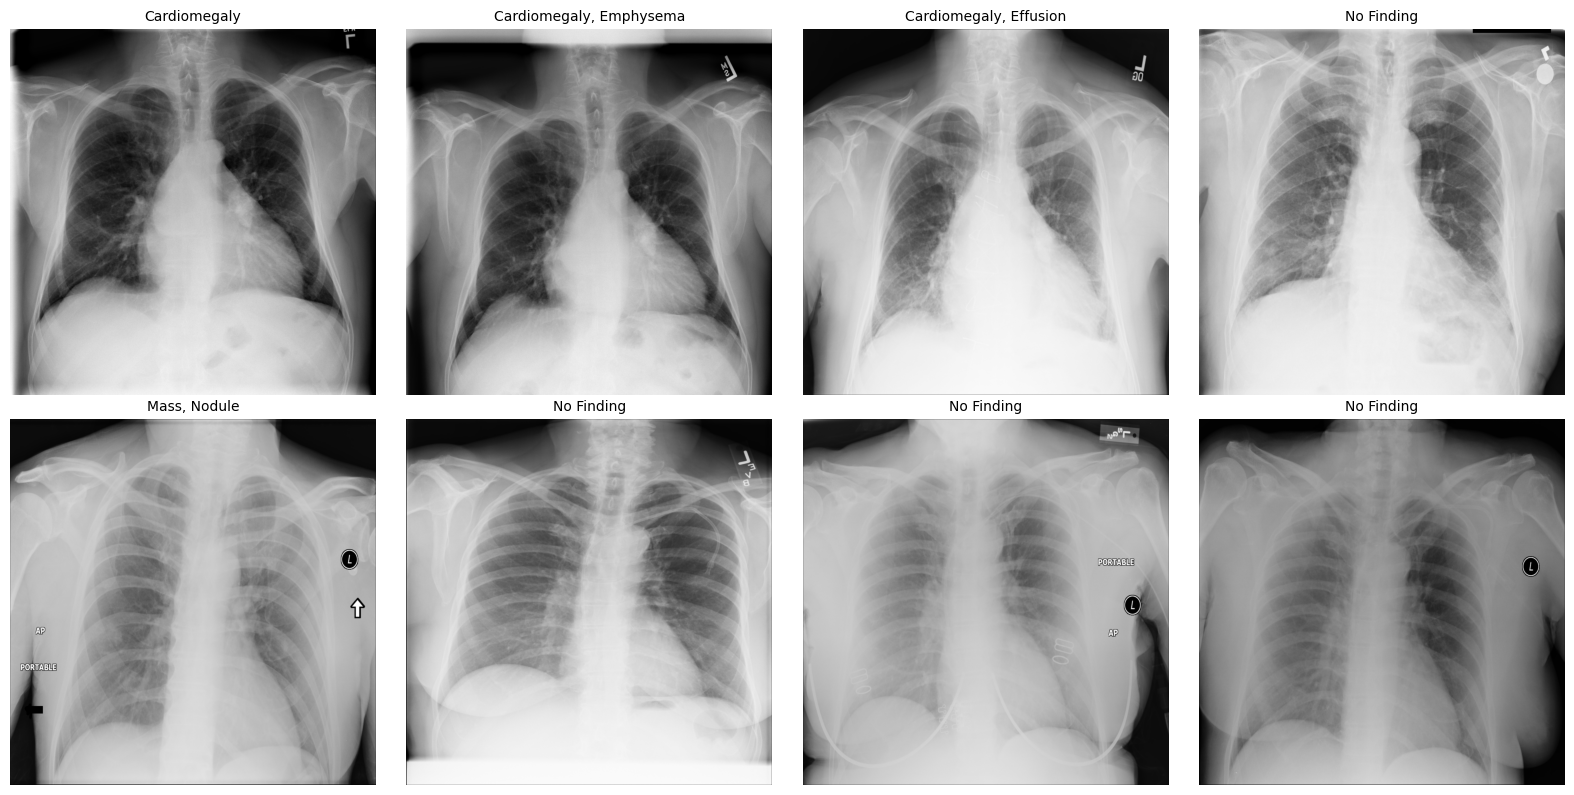


✓ PREPROCESSING COMPLETE!

Dataset ready for training:
  - Train samples: 73916
  - Val samples: 12608
  - Test samples: 25596
  - Number of labels: 14
  - Image size: 512x512
  - Batch size: 32

Next step: Run model training notebook


In [13]:
# ---------- 10) Visualize samples ----------
print("\n[Step 8] Visualizing samples...")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    sample_row = train_df.iloc[i]
    sample_path = image_map[sample_row["Image Index"]]
    img = Image.open(sample_path).convert("RGB")
    
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    
    # Show labels
    present_labels = [label_list[j] for j, v in enumerate(sample_row[label_list].values) if v == 1]
    if not present_labels:
        present_labels = ["No Finding"]
    title = ", ".join(present_labels[:3])  # Show first 3 labels
    if len(present_labels) > 3:
        title += f" +{len(present_labels)-3}"
    axes[i].set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("✓ PREPROCESSING COMPLETE!")
print("="*60)
print(f"\nDataset ready for training:")
print(f"  - Train samples: {len(train_dataset)}")
print(f"  - Val samples: {len(val_dataset)}")
print(f"  - Test samples: {len(test_dataset)}")
print(f"  - Number of labels: {len(label_list)}")
print(f"  - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"\nNext step: Run model training notebook")

In [14]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import numpy as np
import os
import json
import matplotlib.pyplot as plt

In [15]:
NUM_CLASSES = len(label_list)
HEAD_EPOCHS = 5           # Stage 1: train classifier head only
FT_EPOCHS = 20            # Stage 2: fine-tune full model
TOTAL_EPOCHS = HEAD_EPOCHS + FT_EPOCHS  # = 25

HEAD_LR = 1e-3            # Higher LR for head-only training
FT_LR = 2e-5              # Lower LR for full model fine-tuning
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 32  # Uses your existing BATCH_SIZE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_DIR = "/kaggle/working/checkpoints_resnet50"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Choose loss: 'asymmetric' or 'bce'
LOSS_TYPE = "asymmetric"
EARLY_STOP_PATIENCE = 5  # For safety, can be increased

print("="*80)
print("ResNet-50 Two-Stage Training with Asymmetric Loss - 25 epochs")
print("="*80)
print(f"Device: {DEVICE}")
print(f"Num Classes: {NUM_CLASSES}")
print(f"Stage 1 (Head): {HEAD_EPOCHS} epochs @ LR={HEAD_LR}")
print(f"Stage 2 (Fine-tune): {FT_EPOCHS} epochs @ LR={FT_LR}")
print(f"Loss Type: {LOSS_TYPE}")
print("="*80 + "\n")

ResNet-50 Two-Stage Training with Asymmetric Loss - 25 epochs
Device: cuda
Num Classes: 14
Stage 1 (Head): 5 epochs @ LR=0.001
Stage 2 (Fine-tune): 20 epochs @ LR=2e-05
Loss Type: asymmetric



In [16]:
def build_resnet50(num_classes: int, pretrained: bool = True):
    """Build ResNet-50 for multi-label classification"""
    if pretrained:
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    else:
        model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def freeze_backbone(model):
    for name, param in model.named_parameters():
        if 'fc' not in name:
            param.requires_grad = False
    print("✓ Backbone frozen (only classifier trainable)")

def unfreeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = True
    print("✓ Backbone unfrozen (all layers trainable)")

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [17]:
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=0, clip=0.05, eps=1e-8):
        super(AsymmetricLoss, self).__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        x_sigmoid = torch.sigmoid(x)
        xs_pos = x_sigmoid
        xs_neg = 1 - x_sigmoid
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)
        los_pos = y * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            pt0 = xs_pos * y
            pt1 = xs_neg * (1 - y)
            pt = pt0 + pt1
            one_sided_gamma = self.gamma_pos * y + self.gamma_neg * (1 - y)
            one_sided_w = torch.pow(1 - pt, one_sided_gamma)
            loss *= one_sided_w
        return -loss.sum() / y.sum()

In [18]:
def compute_auc_per_class(y_true, y_pred):
    aucs = []
    for i in range(y_true.shape[1]):
        try:
            auc = roc_auc_score(y_true[:, i], y_pred[:, i])
        except ValueError:
            auc = float("nan")
        aucs.append(auc)
    return aucs

def compute_metrics(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred >= threshold).astype(int)
    aucs = compute_auc_per_class(y_true, y_pred)
    mean_auc = np.nanmean([x for x in aucs if not np.isnan(x)])
    accuracy = np.mean(y_true == y_pred_binary)
    from sklearn.metrics import f1_score as sklearn_f1
    f1_macro = sklearn_f1(y_true, y_pred_binary, average='macro', zero_division=0)
    return {
        'mean_auc': mean_auc,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_auc': aucs
    }

In [19]:
# TRAINING & VALIDATION LOOPS
# ========================================================================

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    running_loss = 0.0
    n_samples = 0
    pbar = tqdm(loader, desc="Train", leave=False)
    for imgs, targets in pbar:
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss = criterion(logits, targets)
        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        batch_size = imgs.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    epoch_loss = running_loss / (n_samples + 1e-12)
    return epoch_loss

def validate(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        pbar = tqdm(loader, desc="Val", leave=False)
        for imgs, targets in pbar:
            imgs = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_targets.append(targets.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    metrics = compute_metrics(all_targets, all_preds)
    return metrics

In [20]:

model = build_resnet50(NUM_CLASSES, pretrained=True)
model = model.to(DEVICE)

print(f"Model: ResNet-50; Trainable Params (Total): {sum(p.numel() for p in model.parameters()):,}")

criterion = AsymmetricLoss(gamma_neg=4.0, gamma_pos=0.0, clip=0.05) if LOSS_TYPE == "asymmetric" else nn.BCEWithLogitsLoss()
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

history = {
    'stage1_train_loss': [],
    'stage1_val_metrics': [],
    'stage2_train_loss': [],
    'stage2_val_metrics': [],
}

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s] 


Model: ResNet-50; Trainable Params (Total): 23,536,718


In [21]:
print("="*80)
print("STAGE 1: TRAINING CLASSIFIER HEAD ONLY")
print("="*80 + "\n")

freeze_backbone(model)
print(f"Trainable parameters (Stage 1): {count_trainable_params(model):,}\n")
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_val_auc_stage1 = 0.0

for epoch in range(1, HEAD_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
    val_metrics = validate(model, val_loader, DEVICE)
    val_auc = val_metrics['mean_auc']
    scheduler.step(val_auc)
    elapsed = time.time() - t0
    history['stage1_train_loss'].append(train_loss)
    history['stage1_val_metrics'].append(val_metrics)
    print(f"[Stage 1] Epoch {epoch}/{HEAD_EPOCHS} | Time {elapsed:.0f}s | "
          f"Train Loss {train_loss:.4f} | Val AUC {val_auc:.4f}")
    if val_auc > best_val_auc_stage1:
        best_val_auc_stage1 = val_auc
        torch.save({
            'epoch': epoch,
            'stage': 1,
            'model_state_dict': model.state_dict(),
            'val_auc': val_auc,
        }, os.path.join(CHECKPOINT_DIR, 'best_model_stage1.pth'))
        print(f"  ✓ Best model saved (AUC: {val_auc:.4f})")
print(f"\n✓ Stage 1 Complete | Best Val AUC: {best_val_auc_stage1:.4f}\n")

STAGE 1: TRAINING CLASSIFIER HEAD ONLY

✓ Backbone frozen (only classifier trainable)
Trainable parameters (Stage 1): 28,686



[Stage 1] Epoch 1/5 | Time 1968s | Train Loss 1.0030 | Val AUC 0.7239
  ✓ Best model saved (AUC: 0.7239)


[Stage 1] Epoch 2/5 | Time 1746s | Train Loss 1.0042 | Val AUC 0.7283
  ✓ Best model saved (AUC: 0.7283)


[Stage 1] Epoch 3/5 | Time 1716s | Train Loss 1.0029 | Val AUC 0.7312
  ✓ Best model saved (AUC: 0.7312)


[Stage 1] Epoch 4/5 | Time 1738s | Train Loss 1.0064 | Val AUC 0.7256


[Stage 1] Epoch 5/5 | Time 1821s | Train Loss 1.0066 | Val AUC 0.7262

✓ Stage 1 Complete | Best Val AUC: 0.7312



In [22]:


# # STAGE 2: FINE-TUNE ENTIRE NETWORK
# # ========================================================================

# print("="*80)
# print("STAGE 2: FINE-TUNING ENTIRE NETWORK")
# print("="*80 + "\n")

# unfreeze_backbone(model)
# print(f"Trainable parameters (Stage 2): {count_trainable_params(model):,}\n")
# optimizer = optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=WEIGHT_DECAY)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)  # more patience for long phase

# best_val_auc_stage2 = best_val_auc_stage1
# best_epoch_overall = 2

# epochs_without_improvement = 0
# for epoch in range(1, FT_EPOCHS + 1):
#     t0 = time.time()
#     global_epoch = HEAD_EPOCHS + epoch
#     train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
#     val_metrics = validate(model, val_loader, DEVICE)
#     val_auc = val_metrics['mean_auc']
#     scheduler.step(val_auc)
#     elapsed = time.time() - t0
#     history['stage2_train_loss'].append(train_loss)
#     history['stage2_val_metrics'].append(val_metrics)
#     print(f"[Stage 2] Epoch {epoch}/{FT_EPOCHS} (Global {global_epoch}/{TOTAL_EPOCHS}) | Time {elapsed:.0f}s | "
#           f"Train Loss {train_loss:.4f} | Val AUC {val_auc:.4f}")
#     if val_auc > best_val_auc_stage2:
#         best_val_auc_stage2 = val_auc
#         best_epoch_overall = global_epoch
#         torch.save({
#             'epoch': global_epoch,
#             'stage': 2,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'val_auc': val_auc,
#         }, os.path.join(CHECKPOINT_DIR, 'best_resnet50_model.pth'))
#         print(f"  ✓ Best model saved (AUC: {val_auc:.4f})")
#         epochs_without_improvement = 0
#     else:
#         epochs_without_improvement += 1
#     if epochs_without_improvement >= EARLY_STOP_PATIENCE:
#         print(f"\nEarly stopping triggered at fine-tune epoch {epoch}")
#         break
# print(f"\n✓ Stage 2 Complete | Best Val AUC: {best_val_auc_stage2:.4f}\n")

import time
import torch
import torch.optim as optim
import os

print("="*80)
print("STAGE 2: FINE-TUNING ENTIRE NETWORK")
print("="*80 + "\n")

# --- UPDATE: Set epochs to 2 as requested ---
FT_EPOCHS = 2 
# --------------------------------------------

unfreeze_backbone(model)
print(f"Trainable parameters (Stage 2): {count_trainable_params(model):,}\n")

optimizer = optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_val_auc_stage2 = best_val_auc_stage1
best_epoch_overall = HEAD_EPOCHS # Assumed HEAD_EPOCHS variable exists from stage 1

epochs_without_improvement = 0

for epoch in range(1, FT_EPOCHS + 1):
    t0 = time.time()
    global_epoch = HEAD_EPOCHS + epoch
    
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
    val_metrics = validate(model, val_loader, DEVICE)
    val_auc = val_metrics['mean_auc']
    
    scheduler.step(val_auc)
    
    elapsed = time.time() - t0
    history['stage2_train_loss'].append(train_loss)
    history['stage2_val_metrics'].append(val_metrics)
    
    print(f"[Stage 2] Epoch {epoch}/{FT_EPOCHS} (Global {global_epoch}/{TOTAL_EPOCHS}) | Time {elapsed:.0f}s | "
          f"Train Loss {train_loss:.4f} | Val AUC {val_auc:.4f}")
    
    if val_auc > best_val_auc_stage2:
        best_val_auc_stage2 = val_auc
        best_epoch_overall = global_epoch
        torch.save({
            'epoch': global_epoch,
            'stage': 2,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
        }, os.path.join(CHECKPOINT_DIR, 'best_resnet50_model.pth'))
        print(f"  ✓ Best model saved (AUC: {val_auc:.4f})")
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    # Early stopping check (unlikely to trigger in just 2 epochs unless patience is 0)
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at fine-tune epoch {epoch}")
        break

print(f"\n✓ Stage 2 Complete | Best Val AUC: {best_val_auc_stage2:.4f}\n")

STAGE 2: FINE-TUNING ENTIRE NETWORK

✓ Backbone unfrozen (all layers trainable)
Trainable parameters (Stage 2): 23,536,718



[Stage 2] Epoch 1/2 (Global 6/25) | Time 1897s | Train Loss 0.9425 | Val AUC 0.7822
  ✓ Best model saved (AUC: 0.7822)


[Stage 2] Epoch 2/2 (Global 7/25) | Time 1893s | Train Loss 0.9171 | Val AUC 0.8013
  ✓ Best model saved (AUC: 0.8013)

✓ Stage 2 Complete | Best Val AUC: 0.8013



TEST SET EVALUATION

✓ Loaded best model from epoch 7
  Val AUC: 0.8013



Test Mean AUC: 0.7732
Test Accuracy: 0.8408
Test F1 (macro): 0.2311

Per-Class AUC Scores:
------------------------------------------------------------
✓ Atelectasis              : 0.7381
✓ Cardiomegaly             : 0.7936
✓ Consolidation            : 0.7074
✓ Edema                    : 0.8296
✓ Effusion                 : 0.8005
✓ Emphysema                : 0.8938
✓ Fibrosis                 : 0.7884
✓ Hernia                   : 0.8657
✓ Infiltration             : 0.7013
✓ Mass                     : 0.7344
✓ Nodule                   : 0.6956
✓ Pleural_Thickening       : 0.7300
✓ Pneumonia                : 0.7025
✓ Pneumothorax             : 0.8430

✓ Results saved to test_results.json

Generating plots...



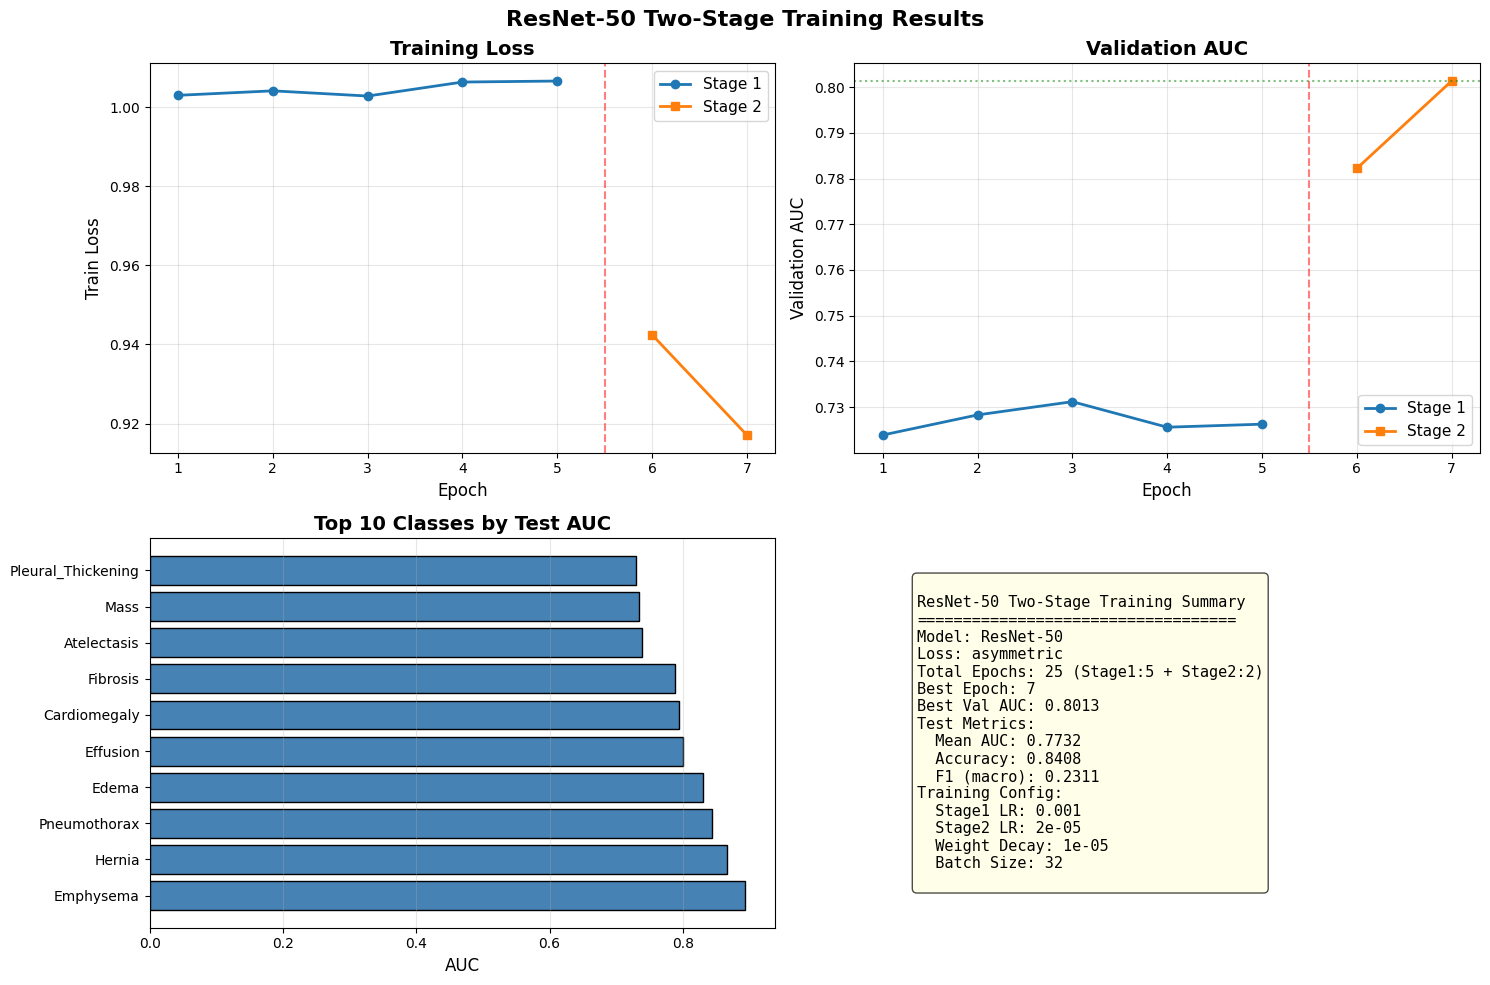

✓ Training complete!


In [23]:
print("="*80)
print("TEST SET EVALUATION")
print("="*80 + "\n")
ckpt_path = os.path.join(CHECKPOINT_DIR, 'best_resnet50_model.pth')
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"✓ Loaded best model from epoch {ckpt['epoch']}")
    print(f"  Val AUC: {ckpt['val_auc']:.4f}\n")
test_metrics = validate(model, test_loader, DEVICE)
print(f"Test Mean AUC: {test_metrics['mean_auc']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test F1 (macro): {test_metrics['f1_macro']:.4f}\n")
print("Per-Class AUC Scores:")
print("-" * 60)
for i, label in enumerate(label_list):
    auc = test_metrics['per_class_auc'][i]
    status = "✓" if not np.isnan(auc) else "✗"
    print(f"{status} {label:25s}: {auc:.4f}")

# ========================================================================
# SAVE RESULTS
# ========================================================================

results = {
    'model': 'ResNet-50',
    'loss_type': LOSS_TYPE,
    'total_epochs': TOTAL_EPOCHS,
    'stage1_epochs': HEAD_EPOCHS,
    'stage2_epochs': FT_EPOCHS,
    'best_epoch': best_epoch_overall,
    'best_val_auc': best_val_auc_stage2,
    'test_metrics': {
        'mean_auc': float(test_metrics['mean_auc']),
        'accuracy': float(test_metrics['accuracy']),
        'f1_macro': float(test_metrics['f1_macro']),
    },
    'per_class_auc': [float(x) if not np.isnan(x) else None for x in test_metrics['per_class_auc']],
    'label_list': label_list
}
with open(os.path.join(CHECKPOINT_DIR, 'test_results.json'), 'w') as f:
    json.dump(results, f, indent=4)
print("\n✓ Results saved to test_results.json")

# ========================================================================
# VISUALIZATION
# ========================================================================

print("\nGenerating plots...\n")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Stage 1 & 2 losses
all_losses = history['stage1_train_loss'] + history['stage2_train_loss']
stage1_len = len(history['stage1_train_loss'])
axes[0, 0].plot(range(1, stage1_len + 1), history['stage1_train_loss'], 'o-', label='Stage 1', linewidth=2)
axes[0, 0].plot(range(stage1_len + 1, stage1_len + len(history['stage2_train_loss']) + 1),
                history['stage2_train_loss'], 's-', label='Stage 2', linewidth=2)
axes[0, 0].axvline(x=stage1_len + 0.5, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Train Loss', fontsize=12)
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
# Stage 1 & 2 AUC
stage1_aucs = [m['mean_auc'] for m in history['stage1_val_metrics']]
stage2_aucs = [m['mean_auc'] for m in history['stage2_val_metrics']]
axes[0, 1].plot(range(1, stage1_len + 1), stage1_aucs, 'o-', label='Stage 1', linewidth=2)
axes[0, 1].plot(range(stage1_len + 1, stage1_len + len(stage2_aucs) + 1), stage2_aucs, 's-', label='Stage 2', linewidth=2)
axes[0, 1].axvline(x=stage1_len + 0.5, color='red', linestyle='--', alpha=0.5)
axes[0, 1].axhline(y=best_val_auc_stage2, color='green', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Validation AUC', fontsize=12)
axes[0, 1].set_title('Validation AUC', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
# Per-class test AUC
top_aucs_idx = np.argsort(test_metrics['per_class_auc'])[::-1][:10]
top_labels = [label_list[i] for i in top_aucs_idx]
top_aucs = [test_metrics['per_class_auc'][i] for i in top_aucs_idx]
axes[1, 0].barh(top_labels, top_aucs, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('AUC', fontsize=12)
axes[1, 0].set_title('Top 10 Classes by Test AUC', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
# Summary
axes[1, 1].axis('off')
summary_text = f"""
ResNet-50 Two-Stage Training Summary
{'='*35}
Model: ResNet-50
Loss: {LOSS_TYPE}
Total Epochs: {TOTAL_EPOCHS} (Stage1:{HEAD_EPOCHS} + Stage2:{FT_EPOCHS})
Best Epoch: {best_epoch_overall}
Best Val AUC: {best_val_auc_stage2:.4f}
Test Metrics:
  Mean AUC: {test_metrics['mean_auc']:.4f}
  Accuracy: {test_metrics['accuracy']:.4f}
  F1 (macro): {test_metrics['f1_macro']:.4f}
Training Config:
  Stage1 LR: {HEAD_LR}
  Stage2 LR: {FT_LR}
  Weight Decay: {WEIGHT_DECAY}
  Batch Size: {BATCH_SIZE}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
                fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
plt.suptitle('ResNet-50 Two-Stage Training Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_results.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Training complete!")
print("="*80)

In [2]:
# Save the model weights
torch.save(model.state_dict(), 'chest_xray.pth')
print("Model saved successfully as 'chest_xray.pth'")

NameError: name 'torch' is not defined